# Synthetic Ransomware Dataset: Overview & Characterization
**Authors:** S.S.S., S.N.M. (Dr. Sumitra N. Motade)  
**Context:** Companion to "Hybrid Quantum-Classical Early Ransomware Detection"

## 1. Introduction
High-quality, labeled datasets that include explicit pre-encryption timestamps are scarce in public ransomware research due to privacy concerns and proprietary nature of telemetry. real endpoint telemetry is often missing precise annotations that mark the moment encryption begins.

To address this, we utilize a **Synthetic Time-Series Dataset** that simulates multivariate host telemetry (CPU usage, Memory I/O, Disk activity, Network counters) across a fixed observation window.

**Why Synthetic?**
1. **Ground Truth Precision**: We know exactly when encryption starts (`t_encrypt`) and when pre-attack drift begins (`t_detect`).
2. **Reproducibility**: Generated via fixed seeds, allowing consistent benchmarks.
3. **Control**: We can inject specific anomalous patterns (linear ramps, variance spikes) that mimic known ransomware behaviors like file enumeration and mass encryption.

This notebook visualizes the data structure, statistical properties, and characteristic signatures of benign vs. malicious samples.

## 2. Dataset Generation Engine

The data is generated using a stochastic process:
- **Benign**: Gaussian noise with minor random spikes (transient system activity).
- **Malicious**: Base noise + Linear Drift (Preparation Phase) + High Amplitude Spike (Encryption Phase).

**Parameters:**
- **Samples**: 2000
- **Sequence Length**: 120 timesteps
- **Channels**: 10 (simulating 10 different system metrics)
- **Class Balance**: 80% Benign, 20% Malicious


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# --- Generation Logic (Identical to Main Experiment) ---
def generate_dataset(n_samples=2000, seq_len=120, n_channels=10, mal_ratio=0.2):
    n_malicious = int(n_samples * mal_ratio)
    n_benign = n_samples - n_malicious
    
    X = np.zeros((n_samples, seq_len, n_channels))
    y = np.zeros(n_samples, dtype=int)
    
    # Metadata
    t_encrypt_gt = np.full(n_samples, np.nan)
    t_detect_gt = np.full(n_samples, np.nan) 
    
    # Random Seed for Consistency
    np.random.seed(42)
    
    # 1. Generate Benign (Noise + Transient Spikes)
    for i in range(n_benign):
        # Baseline noise
        X[i] = np.random.normal(0, 0.4393, (seq_len, n_channels)) + 0.0501 
        
        # Add random transient spikes (legitimate activity)
        num_spikes = np.random.randint(0, 3)
        for _ in range(num_spikes):
            spike_start = np.random.randint(0, seq_len-5)
            X[i, spike_start:spike_start+3, :] += np.random.normal(0.5, 0.2, (3, n_channels))
        
    # 2. Generate Malicious (Drift + Encryption Spike)
    for i in range(n_benign, n_samples):
        y[i] = 1
        
        # Determine Encryption Start (Late in sequence)
        start_t = np.random.randint(int(seq_len*0.6), seq_len-10)
        t_encrypt_gt[i] = start_t
        
        # Determine Early Warning Start (30-70 steps before encryption)
        lead_time = np.random.randint(30, 71) 
        drift_start = max(0, start_t - lead_time)
        t_detect_gt[i] = drift_start
        
        # Base Noise
        X[i] = np.random.normal(0, 0.6, (seq_len, n_channels))
        
        # Add Pre-Encryption Drift (Linear Ramp)
        # Simulates file enumeration / key generation / C2 comms
        drift_len = start_t - drift_start
        if drift_len > 0:
            drift = np.linspace(0, 1.0, drift_len)
            for c in range(n_channels):
                # Add drift to specific channels or all
                X[i, drift_start:start_t, c] += drift
        
        # Add Encryption Burst (High Amplitude)
        # Simulates mass file I/O and CPU pinning
        enc_len = seq_len - start_t
        X[i, start_t:, :] += np.random.normal(2.0, 1.5, (enc_len, n_channels))

    return X, y, t_encrypt_gt, t_detect_gt

# Generate Data
X_raw, y, t_enc, t_det = generate_dataset()
print("Dataset Generated Successfully.")
print(f"Dimensions: {X_raw.shape} (Samples, Timesteps, Channels)")

Dataset Generated Successfully.
Dimensions: (2000, 120, 10) (Samples, Timesteps, Channels)


## 3. Statistical Profile

A quick look at the global statistics separates the valid "normal" range from the "anomalous" range found in malicious samples.


--- Global Statistics ---
           mean       std       min       max
Ch_0   0.190046  0.731342 -4.488733  8.091834
Ch_1   0.191143  0.732722 -3.831475  8.064051
Ch_2   0.192269  0.731216 -4.119047  8.671897
Ch_3   0.190009  0.728807 -4.145534  8.620224
Ch_4   0.187742  0.730049 -4.578646  7.486757
Ch_5   0.190238  0.729011 -4.089448  7.520233
Ch_6   0.190140  0.733127 -4.459601  9.030903
Ch_7   0.190173  0.726612 -4.357096  7.671909
Ch_8   0.189697  0.728049 -3.529638  8.028883
Ch_9   0.188255  0.731427 -6.326955  8.382933
Label  0.200000  0.400001  0.000000  1.000000


C:\Users\Shashwat\AppData\Local\Temp\ipykernel_15816\1157950709.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


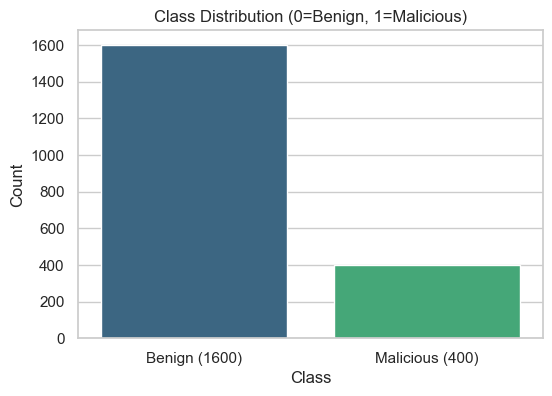

In [6]:
# Create DataFrame for Global Stats
flat_data = X_raw.reshape(-1, 10)
columns = [f"Ch_{i}" for i in range(10)]
df_flat = pd.DataFrame(flat_data, columns=columns)
df_flat['Label'] = np.repeat(y, 120)

print("--- Global Statistics ---")
print(df_flat.describe().T[['mean', 'std', 'min', 'max']])

# Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="viridis")
plt.title("Class Distribution (0=Benign, 1=Malicious)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ['Benign (1600)', 'Malicious (400)'])
plt.show()

## 4. Visualizing Ransomware Signatures

This is the most critical visualization. We compare a typical Benign trajectory with a Malicious one to highlight the **"Window of Opportunity"**.

- **Green Dotted Line**: `t_detect_gt`. The moment varying behavior begins (e.g., file enumeration). This is where we WANT to detect.
- **Red Dashed Line**: `t_encrypt_gt`. The moment mass encryption starts. This is where damage becomes irreversible.


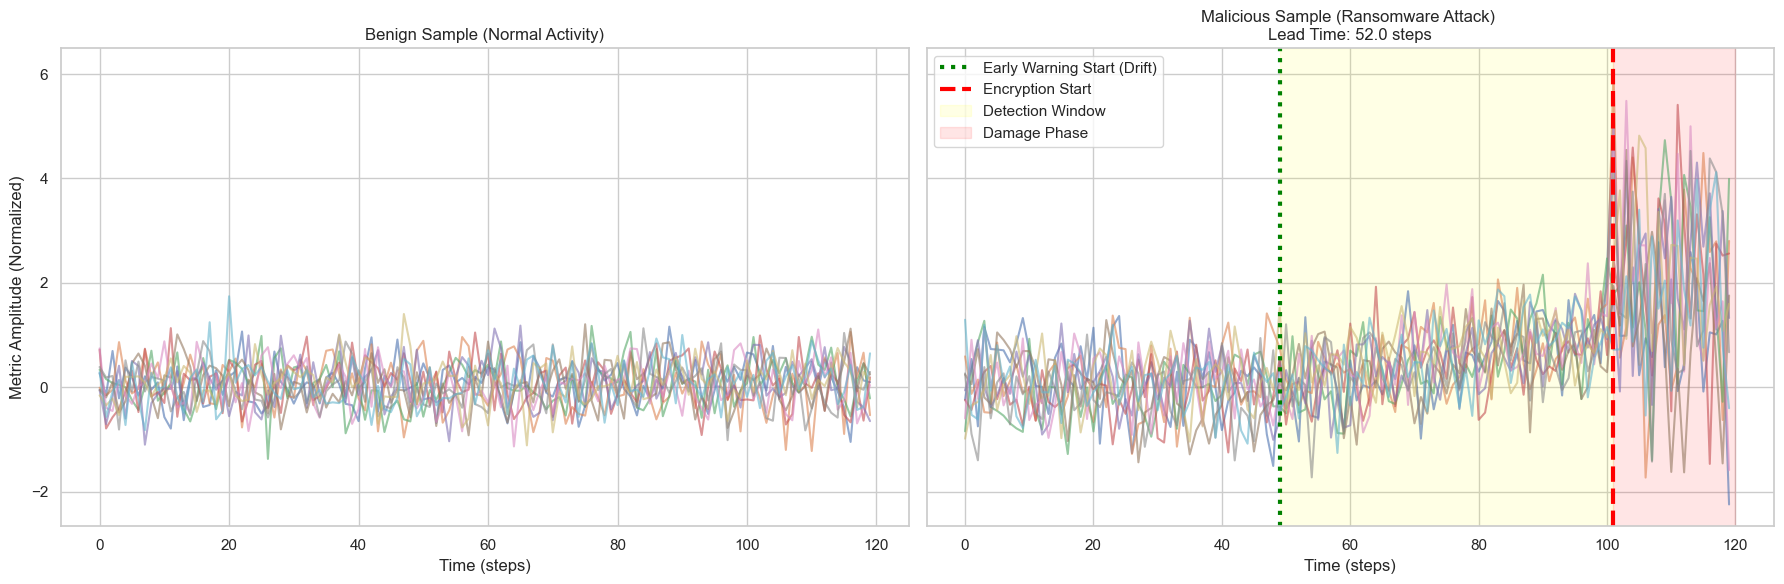

In [7]:
# Select specific samples for clarity
benign_idx = 0 
mal_idx = 1605 # Arbitrary malicious sample index

# Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Benign Plot
axes[0].plot(X_raw[benign_idx], alpha=0.6)
axes[0].set_title("Benign Sample (Normal Activity)")
axes[0].set_xlabel("Time (steps)")
axes[0].set_ylabel("Metric Amplitude (Normalized)")
axes[0].grid(True)

# Malicious Plot
axes[1].plot(X_raw[mal_idx], alpha=0.6)
# Annotate Ground Truths
enc_t = t_enc[mal_idx]
det_t = t_det[mal_idx]

axes[1].axvline(det_t, color='green', linestyle=':', linewidth=3, label='Early Warning Start (Drift)')
axes[1].axvline(enc_t, color='red', linestyle='--', linewidth=3, label='Encryption Start')
axes[1].axvspan(det_t, enc_t, color='yellow', alpha=0.1, label='Detection Window')
axes[1].axvspan(enc_t, 120, color='red', alpha=0.1, label='Damage Phase')

axes[1].set_title(f"Malicious Sample (Ransomware Attack) \nLead Time: {enc_t - det_t} steps")
axes[1].set_xlabel("Time (steps)")
axes[1].legend(loc='upper left')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Heatmap View
Visualizing all 10 channels simultaneously for the malicious sample shows the correlation of the attack across system metrics (e.g., CPU and Disk spiking together).


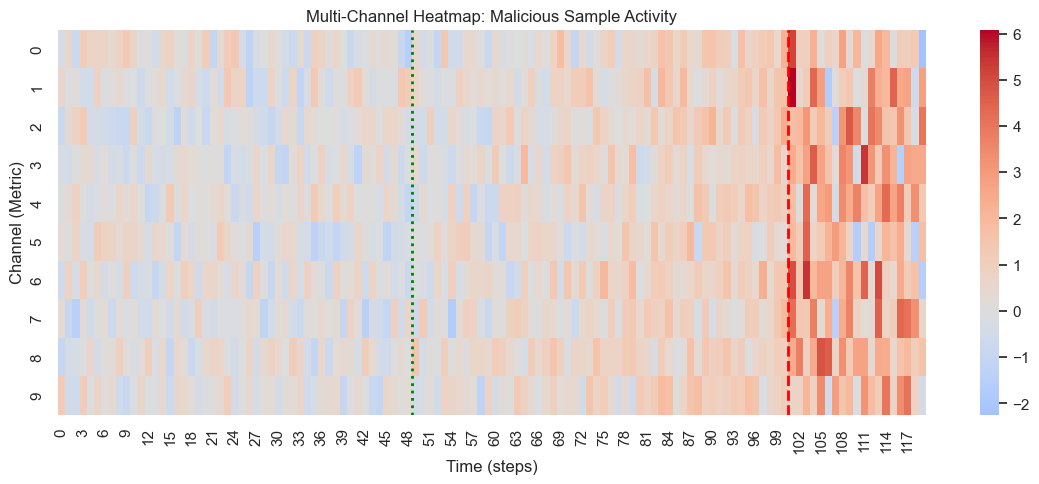

In [8]:
plt.figure(figsize=(14, 5))
sns.heatmap(X_raw[mal_idx].T, cmap="coolwarm", center=0)
plt.title("Multi-Channel Heatmap: Malicious Sample Activity")
plt.xlabel("Time (steps)")
plt.ylabel("Channel (Metric)")
# Draw event lines
plt.axvline(det_t, color='green', linestyle=':', linewidth=2)
plt.axvline(enc_t, color='red', linestyle='--', linewidth=2)
plt.show()

## 5. Temporal Distributions

Understanding the distribution of `t_encrypt` is vital. If encryption happens too early (e.g., step 5), there is no data to detect. Our dataset places encryption late (60-90% of window) to allow for sufficient history.


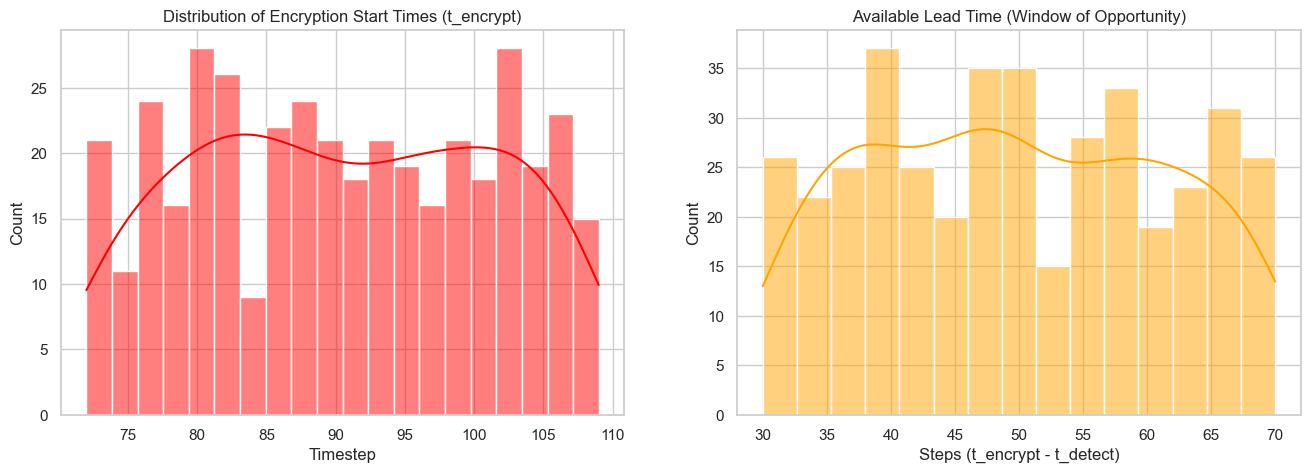

In [9]:
# Filter out NaNs (Benign samples have no encryption time)
valid_t_enc = t_enc[~np.isnan(t_enc)]
valid_t_det = t_det[~np.isnan(t_det)]
lead_times = valid_t_enc - valid_t_det

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Encryption Start Distribution
sns.histplot(valid_t_enc, kde=True, ax=ax[0], color='red', bins=20)
ax[0].set_title("Distribution of Encryption Start Times (t_encrypt)")
ax[0].set_xlabel("Timestep")

# Lead Time Distribution
sns.histplot(lead_times, kde=True, ax=ax[1], color='orange', bins=15)
ax[1].set_title("Available Lead Time (Window of Opportunity)")
ax[1].set_xlabel("Steps (t_encrypt - t_detect)")

plt.show()

## 6. Data Export Structure

For compatibility with classical ML libraries (Scikit-Learn, XGBoost), the 3D data `(2000, 120, 10)` is often flattened into 2D `(2000, 1200)`.

**CSV Layout:**
- `seq_0_0` ... `seq_119_9`: Feature columns.
- `label`: 0 or 1.
- `t_encrypt`: Ground truth integer.
- `t_detect`: Ground truth integer.


In [10]:
# Create Flattened DataFrame representation
# Reshape (N, 120, 10) -> (N, 1200)
X_flat = X_raw.reshape(X_raw.shape[0], -1)
col_names = [f"seq_{t}_{c}" for t in range(120) for c in range(10)]

df_export = pd.DataFrame(X_flat, columns=col_names)
df_export['label'] = y
df_export['t_encrypt_gt'] = t_enc
df_export['t_detect_gt'] = t_det

print(f"Export DataFrame Shape: {df_export.shape}")
print("\nFirst 5 rows (Preview):")
display(df_export.head())

# Optional: Save to CSV
# df_export.to_csv("synthetic_ransomware_dataset.csv", index=False)

Export DataFrame Shape: (2000, 1203)

First 5 rows (Preview):


,seq_0_0,seq_0_1,seq_0_2,seq_0_3,seq_0_4,seq_0_5,seq_0_6,seq_0_7,seq_0_8,seq_0_9,...,seq_119_3,seq_119_4,seq_119_5,seq_119_6,seq_119_7,seq_119_8,seq_119_9,label,t_encrypt_gt,t_detect_gt
0,0.268307,-0.010640,0.334630,0.719167,-0.052764,-0.052756,0.743848,0.387234,-0.156140,0.288447,...,0.190580,-0.649702,0.243601,0.041473,0.292809,0.148465,0.649367,0,NaN,NaN
1,0.257433,0.111257,0.579963,0.218779,-0.074636,0.226344,0.269591,-0.519398,0.555040,-0.082087,...,0.224035,0.013469,0.131675,0.136786,-0.306931,0.708427,0.598240,0,NaN,NaN
2,-0.141771,-0.655669,0.818692,0.656973,-0.517591,0.353089,-0.170857,0.165850,0.179353,-0.052875,...,-0.228542,-0.053562,0.377021,0.235285,0.167313,-0.098876,0.212668,0,NaN,NaN
3,0.421540,0.555831,0.293193,-0.111303,-0.039397,0.843703,-0.103967,0.511362,0.198975,-0.096686,...,0.075108,-0.247390,0.232651,-0.071157,0.168148,-0.409644,-0.314043,0,NaN,NaN
4,-0.570126,-0.054788,0.898437,0.427449,-0.116384,-0.771025,-0.315613,-0.567764,-0.760412,0.395210,...,0.377893,-0.398652,-0.351123,0.693461,0.972790,0.047719,0.803616,0,NaN,NaN
